In [8]:
import pandas as pd
df = pd.read_csv("customer_shopping_data.csv")
import matplotlib.pyplot as plt


In [10]:
df["total_revenue"] = df["quantity"] * df["price"]

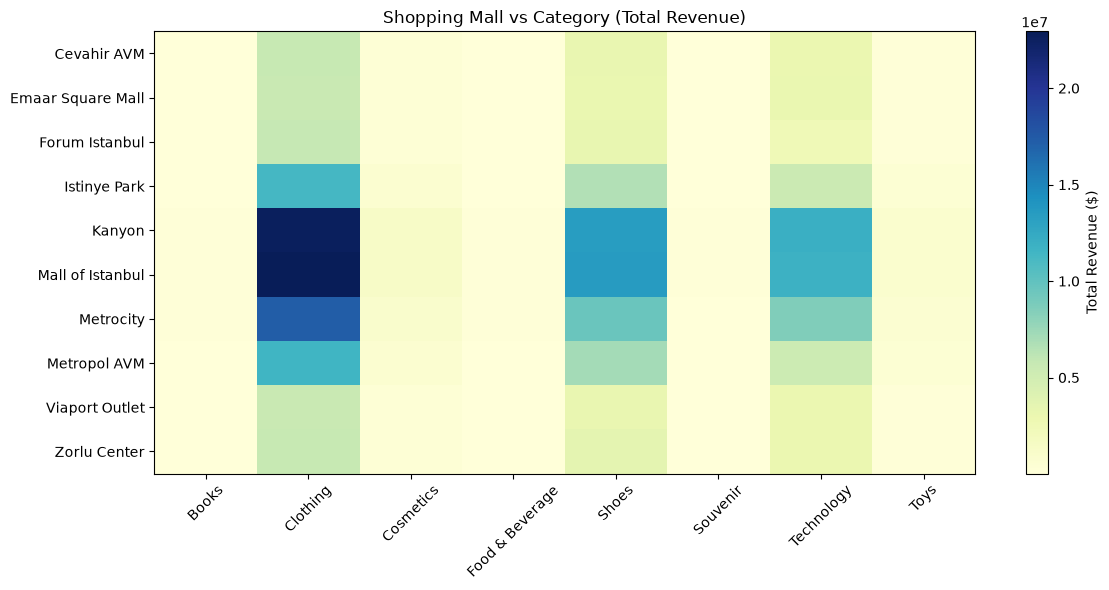

In [11]:
pivot_table = pd.pivot_table(
    df,
    values="total_revenue",
    index="shopping_mall",
    columns="category",
    aggfunc="sum",
    fill_value=0
)

plt.figure(figsize=(12, 6))
plt.imshow(pivot_table, cmap="YlGnBu", aspect="auto")
plt.colorbar(label="Total Revenue ($)")
plt.xticks(range(len(pivot_table.columns)), pivot_table.columns, rotation=45)
plt.yticks(range(len(pivot_table.index)), pivot_table.index)
plt.title("Shopping Mall vs Category (Total Revenue)")
plt.tight_layout()
plt.show()

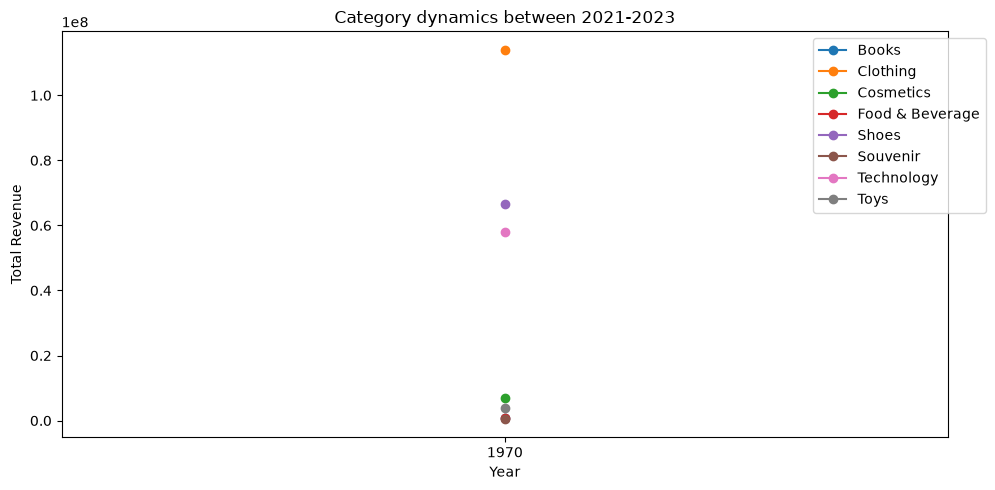

In [17]:
df["invoice_date"] = pd.to_datetime(df["invoice_date"], format="mixed")
df["year"] = df["invoice_date"].dt.year

df["total_revenue"] = df["quantity"] * df["price"]

yearly_cat = df.groupby(["year", "category"])["total_revenue"].sum().unstack()

plt.figure(figsize=(10, 5))

plt.plot(yearly_cat.index.astype(str), yearly_cat.values, marker='o')

plt.title("Category dynamics between 2021-2023")
plt.xlabel("Year")
plt.ylabel("Total Revenue")
plt.legend(yearly_cat.columns, bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

In [14]:
pivot_multi = pd.pivot_table(
    df,
    values="total_revenue",
    index=["shopping_mall", "category"],
    columns="year",
    aggfunc="sum",
    fill_value=0
)

print(pivot_multi)

year                                 1970
shopping_mall category                   
Cevahir AVM   Books              44541.00
              Clothing         5706321.28
              Cosmetics         321214.00
              Food & Beverage    44010.45
              Shoes            3243918.85
...                                   ...
Zorlu Center  Food & Beverage    41955.06
              Shoes            3535601.47
              Souvenir           28996.56
              Technology       2987250.00
              Toys              197550.08

[80 rows x 1 columns]


<Figure size 1200x600 with 0 Axes>

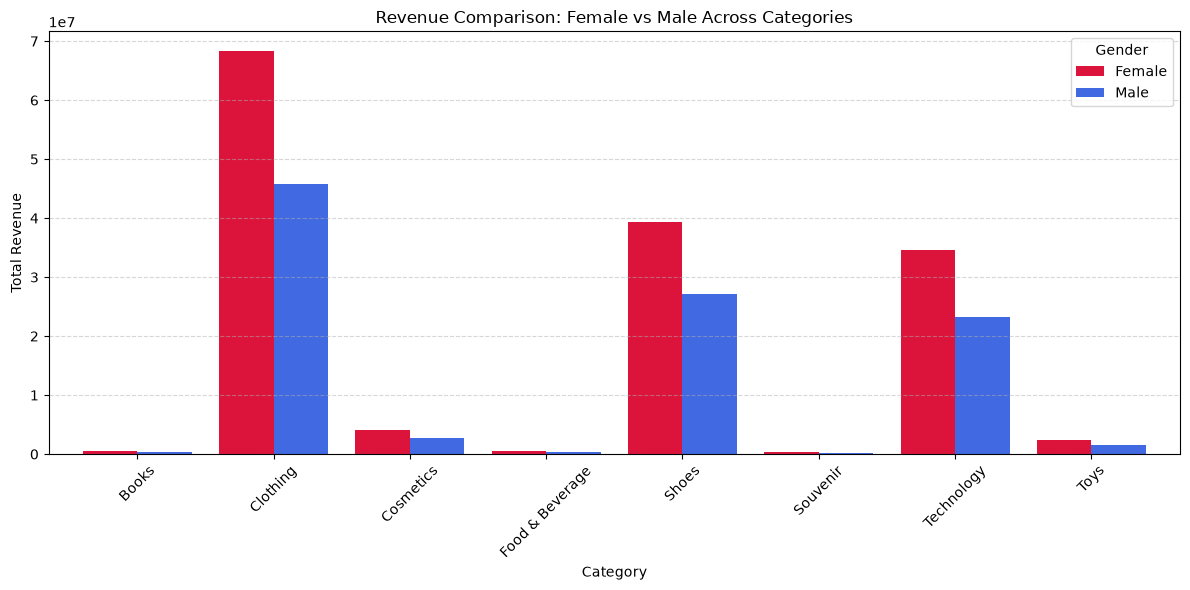

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

df["total_revenue"] = df["quantity"] * df["price"]

gender_cat = df.groupby(["category", "gender"])["total_revenue"].sum().unstack()

plt.figure(figsize=(12, 6))

gender_cat.plot(kind='bar', figsize=(12, 6), color=['crimson', 'royalblue'], width=0.8)

plt.title("Revenue Comparison: Female vs Male Across Categories")
plt.xlabel("Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.legend(title="Gender")
plt.grid(axis='y', linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()